## Default setup for a single flap of the FOSWEC

In [1]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot

import logging 
logging.getLogger().setLevel(logging.INFO)

In [2]:
# Frequency object
wavefreq    = 1/2.61 # Hz
f1          = wavefreq
nfreq       = 10
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

# Define waves object
amplitude   = 0.136 # m
phase       = 0 # degrees
wavedir     = 0 # degrees
waves       = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_0"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.42], name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_0 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


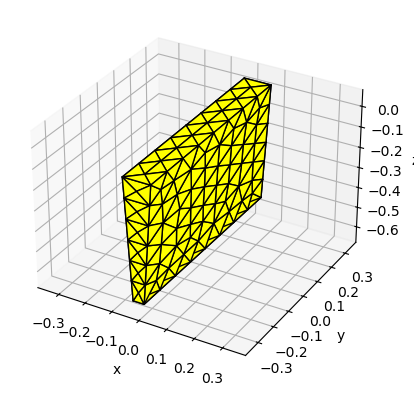

In [3]:
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [0, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin\

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)

#axis = cpt.Axis(vector=(0, 1, 0), point=(0, 0, -flapDraft))
#flap1.add_rotation_dof(name="Pitch_about_hinge", axis=axis)
#flap1.rotation_center = (0, 0, -flapDraft)

# try specifying cg at hinge so Capytaine calculates hydrostatics around hinge
flap1.center_of_mass = flap1CG
flap1.rotation_center = (0, 0, -flapDraft)
flap1.add_rotation_dof(name='Pitch')

flap_mass = 23.1
flap_inertia_cg = 1.19
flap_inertia_hinge = flap_inertia_cg + flap_mass*cgHeightAboveHinge**2
flap1.mass = flap_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([flap_inertia_hinge]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()
#flap1.hydrostatic_stiffness = 87 # Nm/rad

flap1.show_matplotlib()
#flap1.show()

In [4]:
# run BEM calculations
bem_data_file = 'foswec_1_flap_WOT.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(flap1, freq, depth=2)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data) # saves BEM data to file

In [5]:
# create function that loops through values of mass added on top of flap and optimizes control+stiffness
# it should return the new cg height, mass, inertia, hydrostatic_stiffness, maximum position, maximum torque, optimal stiffness, and electrical power

# add an optimization variable for the stiffness
nstate_opt = 2*nfreq + 1
bounds_opt = tuple([(-1e10, 1e10)] * (nstate_opt - 1) + [(0, 1e10)])

x_wec_0 = np.zeros((2*nfreq,))
x_wec_0 = np.repeat(np.squeeze(waves),2)
x_opt_0 = np.zeros((nstate_opt,))
x_opt_0[-1] = 20

options = {'maxiter': 200}
scale_x_wec = 1e1
scale_x_opt = 1e-1
scale_obj = 1e-1

def change_gear_ratio(gear_ratio):

    ## PTO impedance definition
    omega = bem_data.omega.values
    gear_ratio = gear_ratio # 3.75
    torque_constant = 1.021
    winding_resistance = 1.082
    winding_inductance = 0.0
    drivetrain_inertia = 0.00095
    drivetrain_friction = 1.0
    drivetrain_stiffness = 0.0

    drivetrain_impedance = (1j*omega*drivetrain_inertia +
                            drivetrain_friction +
                            1/(1j*omega)*drivetrain_stiffness)

    winding_impedance = winding_resistance + 1j*omega*winding_inductance


    pto_impedance_11 = -1* gear_ratio**2 * drivetrain_impedance
    off_diag = np.sqrt(3.0/2.0) * torque_constant * gear_ratio
    pto_impedance_12 = -1*(off_diag+0j) * np.ones(omega.shape)
    pto_impedance_21 = -1*(off_diag+0j) * np.ones(omega.shape)
    pto_impedance_22 = winding_impedance
    pto_impedance = np.array([[pto_impedance_11, pto_impedance_12],
                                [pto_impedance_21, pto_impedance_22]])

    ndof = 1
    name = ["flap_pitch",]
    kinematics = np.eye(ndof)
    controller = wot.controllers.unstructured_controller()
    loss = None
    pto = wot.pto.PTO(ndof, kinematics, controller, pto_impedance, loss, name)

    # PTO dynamics forcing function and drivetrain spring stiffness

    def drivetrain_stiffness_torque(wec, x_wec, x_opt, wave, nsubsteps=1):
        pos = wec.vec_to_dofmat(x_wec)
        time_matrix = wec.time_mat_nsubsteps(nsubsteps)
        drivetrain_spring = -x_opt[-1]*pos
        spring_torque = jnp.dot(time_matrix, drivetrain_spring)
        return spring_torque

    f_add = {'PTO': pto.force_on_wec, 'drivetrain_stiffness': drivetrain_stiffness_torque}

    # from Daniel:
    # max torque is Kt*46.5 from motor
    # max torque is Kt*40 from drive
    # Max rms torque is Kt*20 from drive
    max_torque = 40*torque_constant
    max_rms_torque = 20*torque_constant
    max_pos = jnp.pi/2
    nsubsteps = 4

    def const_motor_torque(wec, x_wec, x_opt, wave): # Format for scipy.optimize.minimize
        pto_torque = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
        motor_torque = pto_torque/gear_ratio
        return max_torque - jnp.abs(motor_torque.flatten())

    def const_motor_rms_torque(wec, x_wec, x_opt, wave): # Format for scipy.optimize.minimize
        pto_torque = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
        motor_torque = pto_torque/gear_ratio
        return max_rms_torque - jnp.sqrt(jnp.mean(motor_torque.flatten()**2) + 1e-12)

    def const_flap_rotation(wec, x_wec, x_opt, wave): # Format for scipy.optimize.minimize
        pos = wec.vec_to_dofmat(x_wec)
        time_matrix = wec.time_mat_nsubsteps(nsubsteps)
        pos_td = jnp.dot(time_matrix, pos)
        return max_pos - jnp.abs(pos_td.flatten())

    constraints = [{'type': 'ineq', 'fun': const_motor_torque}, {'type': 'ineq', 'fun': const_flap_rotation}, {'type': 'ineq', 'fun': const_motor_rms_torque}]

    wec = wot.WEC.from_bem(
        bem_data,
        constraints=constraints,
        friction=24,
        f_add=f_add,
    )

    obj_fun = pto.average_power

    results = wec.solve(
        waves,
        obj_fun,
        nstate_opt,
        optim_options=options,
        scale_x_wec=scale_x_wec,
        scale_x_opt=scale_x_opt,
        scale_obj=scale_obj,
        x_wec_0=x_wec_0,
        x_opt_0=x_opt_0,
        bounds_opt=bounds_opt,
        )

    opt_average_power = results[0].fun
    print(f'Optimal average mechanical power: {opt_average_power} W')

    nsubsteps = 5
    pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)
    wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)

    return {
        "gear_ratio": gear_ratio,
        "hydrostatic_stiffness": flap1.hydrostatic_stiffness,
        "max_pos": np.max(wec_tdom.sel(realization=0)['pos']),
        "max_torque": np.max(pto_tdom.sel(realization=0)['force']/gear_ratio),
        "opt_stiffness": results[0].x[-1],
        "opt_power": opt_average_power,
    }

In [6]:
gear_ratio_vec = np.linspace(1, 10, 10)

all_res = []

for gear_ratio in gear_ratio_vec:
    res = change_gear_ratio(gear_ratio)
    all_res.append(res)

max_pos_vals = [r["max_pos"] for r in all_res]
max_torque_vals = [r["max_torque"] for r in all_res]
opt_stiffness_vals = [r["opt_stiffness"] for r in all_res]
opt_power_vals = [r["opt_power"] for r in all_res]

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.61e+00, 3.14e+00, 3.55e+01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.19e+00, 1.78e+00, 2.66e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.99e+00, 2.16e+00, 1.40e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.82e+00, 2.00e+00, 4.12e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.91e+00, 2.06e+00, -4.01e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.91e+00, 2.07e+00, -4.66e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.91e+00, 2.08e+00, -4.66e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.91e+00, 2.10e+00, -4.68e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.92e+00, 2.23e+00, -4.77e-02]
INFO:wecopttool.core:Scaled [max(x_

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.09908172663457779
            Iterations: 28
            Function evaluations: 39
            Gradient evaluations: 28
Optimal average mechanical power: -0.9908172663457778 W


INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.58e+00, 3.15e+00, 7.15e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.48e+00, 1.98e+00, 1.66e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.48e+00, 1.90e+00, -1.38e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.43e+00, 1.94e+00, -1.52e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.44e+00, 1.95e+00, -1.53e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.46e+00, 1.97e+00, -1.54e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.55e+00, 2.12e+00, -1.56e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.18e+00, 3.16e+00, -1.72e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.58e+00, 3.79e+00, -1.82e-01]
INFO:wecopttool.core:Scaled [max(

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.27943887177414983
            Iterations: 24
            Function evaluations: 26
            Gradient evaluations: 24
Optimal average mechanical power: -2.7943887177414983 W


INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.55e+00, 3.17e+00, 2.17e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.19e+00, 2.58e+00, 7.20e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.34e+00, 2.13e+00, -2.63e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.36e+00, 2.15e+00, -2.65e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.40e+00, 2.20e+00, -2.67e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.43e+00, 2.26e+00, -2.68e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.59e+00, 2.59e+00, -2.73e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [4.93e+00, 3.32e+00, -2.86e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.57e+00, 4.72e+00, -3.15e-01]
INFO:wecopttool.core:Scaled [max(

...

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.2754623773567494
            Iterations: 24
            Function evaluations: 25
            Gradient evaluations: 24
Optimal average mechanical power: -2.7546237735674937 W


INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.20e+00, 3.49e+00, 1.98e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.62e+00, 4.33e+00, 4.21e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.52e+00, 5.04e+00, -1.70e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.64e+00, 5.01e+00, -2.01e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.75e+00, 4.96e+00, -2.12e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.77e+00, 4.94e+00, -2.16e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.80e+00, 4.92e+00, -2.26e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.77e+00, 4.94e+00, -2.30e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.74e+00, 4.95e+00, -2.31e-01]
INFO:wecopttool.core:Scaled [max(

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.2379759381000804
            Iterations: 25
            Function evaluations: 26
            Gradient evaluations: 25
Optimal average mechanical power: -2.3797593810008038 W


INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.20e+00, 3.57e+00, 2.62e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.32e+00, 4.60e+00, 4.97e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.26e+00, 5.24e+00, -1.36e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.40e+00, 5.21e+00, -1.76e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.48e+00, 5.17e+00, -1.83e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.50e+00, 5.16e+00, -1.86e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.53e+00, 5.13e+00, -1.95e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.52e+00, 5.14e+00, -2.00e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.49e+00, 5.16e+00, -2.01e-01]
INFO:wecopttool.core:Scaled [max(

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.20606347415158371
            Iterations: 26
            Function evaluations: 27
            Gradient evaluations: 26
Optimal average mechanical power: -2.060634741515837 W


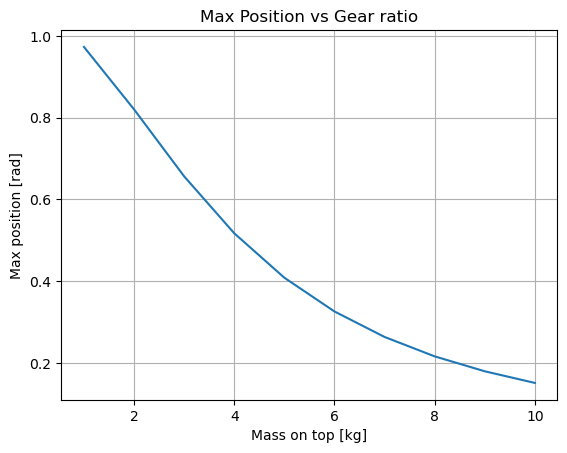

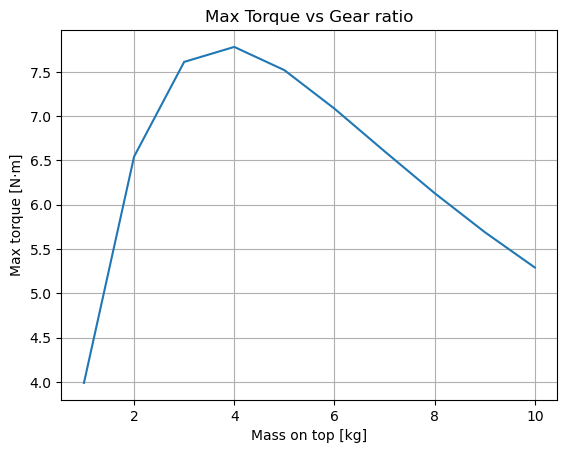

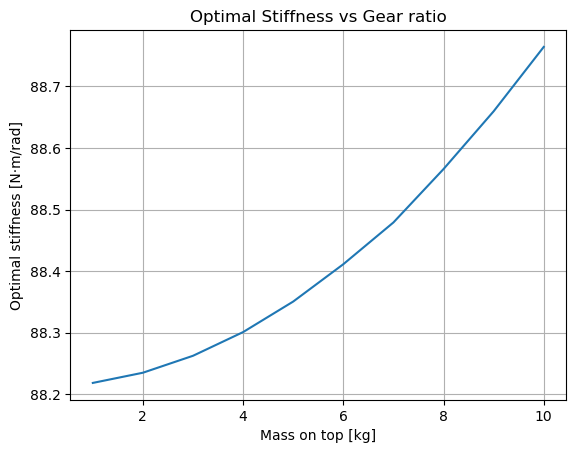

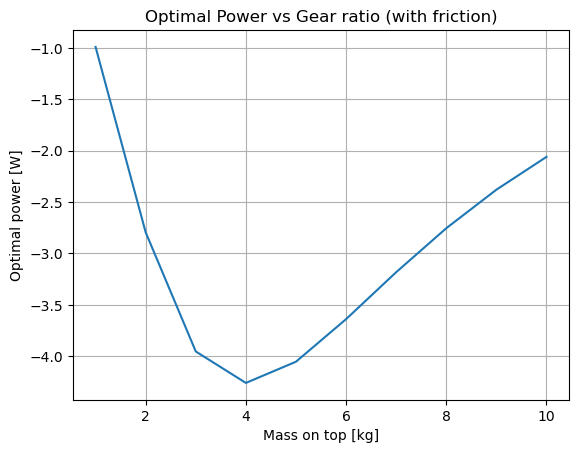

In [7]:


plt.figure()
plt.plot(gear_ratio_vec, max_pos_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Max position [rad]")
plt.title("Max Position vs Gear ratio")
plt.grid(True)
#plt.ylim([0.5, 0.6])

plt.figure()
plt.plot(gear_ratio_vec, max_torque_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Max torque [N·m]")
plt.title("Max Torque vs Gear ratio")
plt.grid(True)
#plt.ylim([2.5, 3])

plt.figure()
plt.plot(gear_ratio_vec, opt_stiffness_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Optimal stiffness [N·m/rad]")
plt.title("Optimal Stiffness vs Gear ratio")
plt.grid(True)


plt.figure()
plt.plot(gear_ratio_vec, opt_power_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Optimal power [W]")
plt.title("Optimal Power vs Gear ratio (with friction)")
plt.grid(True)
#plt.ylim([-17, -16])